In [1]:
# Step 1 - We will prepare Monthly Sales 
import pandas as pd 
df = pd.read_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/cleaned_data.csv")
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

monthly_sales = df.groupby(
    df["order_purchase_timestamp"].dt.to_period("M")
)["order_total_price"].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.head()

order_purchase_timestamp
2016-09-01       610.19
2016-10-01     63396.47
2016-12-01        10.90
2017-01-01    169317.83
2017-02-01    298680.31
Name: order_total_price, dtype: float64

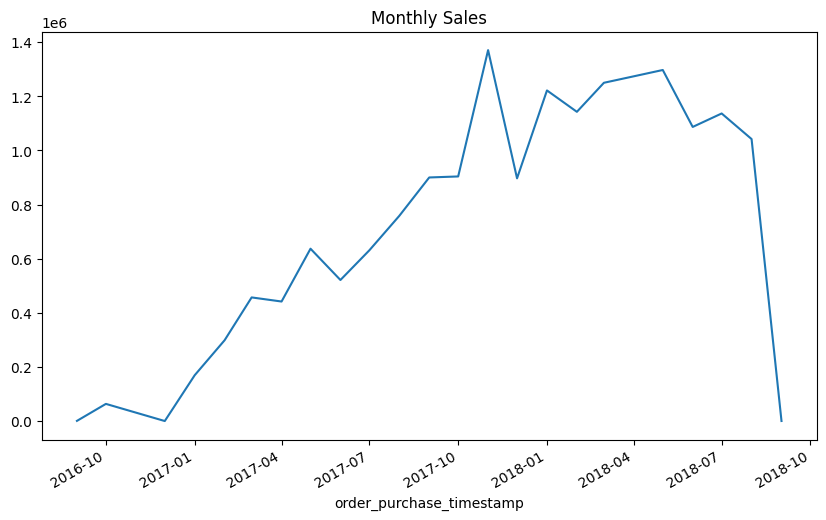

In [2]:
# Step 2 - We will Plot Time Series 
import matplotlib.pyplot as plt

monthly_sales.plot(figsize = (10, 6))
plt.title("Monthly Sales")
plt.show()

In [3]:
# Step 3 - We will check Data Stationarity 
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)
print("ADF Statistic :", result[0])
print("p - value :", result[1])

ADF Statistic : -1.5315883087973956
p - value : 0.5178312307368034


In [4]:
# Step 4 - Perform ARIMA 
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales, order = (1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps = 6)
print(forecast)

24    355130.845349
25    152366.088055
26    268183.513846
27    202029.630420
28    239816.140200
29    218232.821921
Name: predicted_mean, dtype: float64


/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/ts

/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/statsmodels/ts

=== ARIMA Evaluation (last 6 months as test) ===
  MAE  : 284551.96
  RMSE : 503665.86
  MAPE : 139340.98%


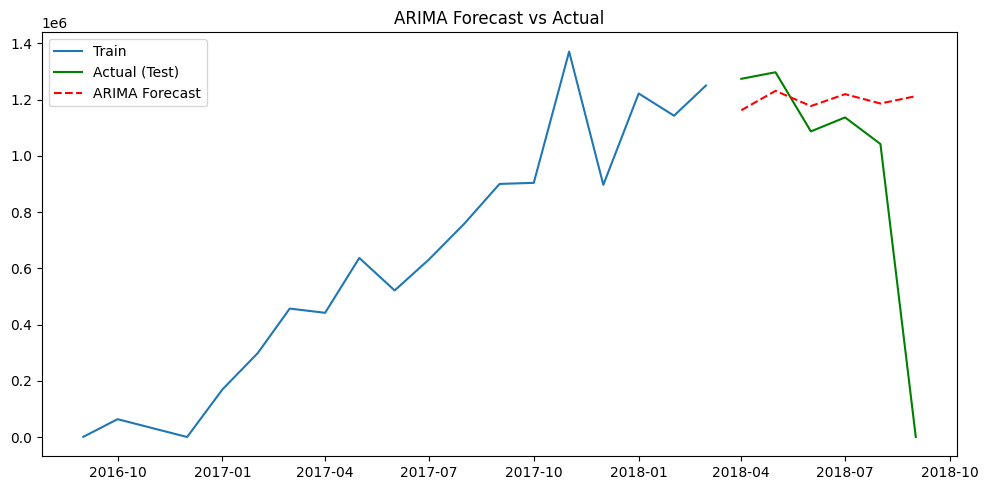

In [ ]:
# Step 5 - Perform ARIMA Model Metrics (Train/Test Split)
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use last 6 months as test set
TEST_STEPS = 6
train_data = monthly_sales.iloc[:-TEST_STEPS]
test_data  = monthly_sales.iloc[-TEST_STEPS:]

# Retrain ARIMA on train split
from statsmodels.tsa.arima.model import ARIMA
arima_train = ARIMA(train_data, order=(1, 1, 1))
arima_fit   = arima_train.fit()
arima_pred  = arima_fit.forecast(steps=TEST_STEPS)

mae  = mean_absolute_error(test_data, arima_pred)
rmse = np.sqrt(mean_squared_error(test_data, arima_pred))
mape = np.mean(np.abs((test_data.values - arima_pred.values) / test_data.values)) * 100

print('=== ARIMA Evaluation (last 6 months as test) ===')
print(f'  MAE  : {mae:.2f}')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAPE : {mape:.2f}%')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data.values, label='Train')
plt.plot(test_data.index, test_data.values, label='Actual (Test)', color='green')
plt.plot(test_data.index, arima_pred.values, label='ARIMA Forecast', linestyle='--', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

Importing plotly failed. Interactive plots will not work.


13:55:16 - cmdstanpy - INFO - Chain [1] start processing
13:55:16 - cmdstanpy - INFO - Chain [1] done processing
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


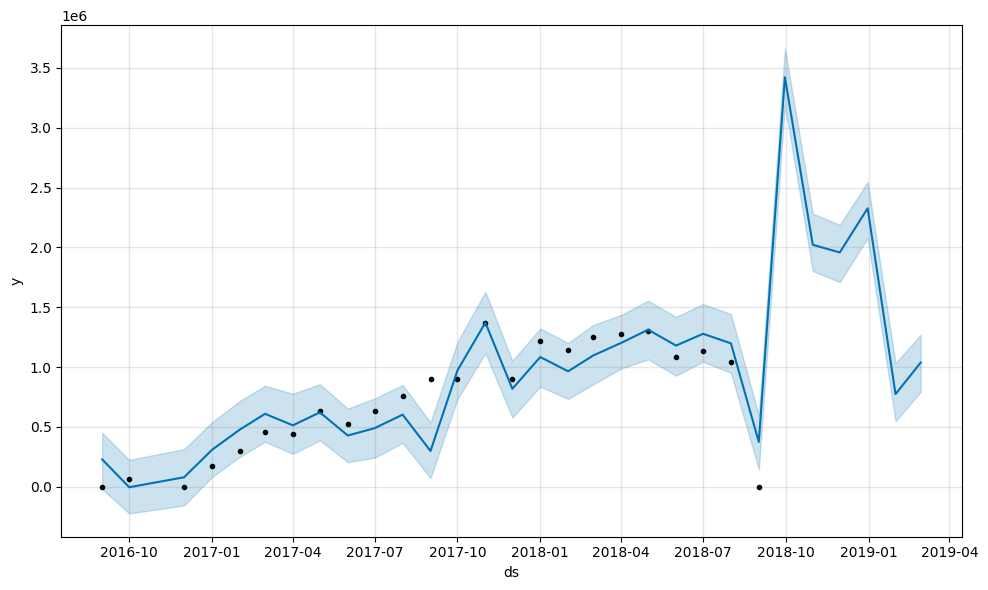

In [ ]:
# Step 6 - Perform Prophet
from prophet import Prophet 

prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods = 6, freq = 'M')
forecast = model.predict(future)

model.plot(forecast)
plt.show()

13:55:17 - cmdstanpy - INFO - Chain [1] start processing
13:55:18 - cmdstanpy - INFO - Chain [1] done processing
/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


=== Prophet Evaluation (last 6 months as test) ===
  MAE  : 602231.00
  RMSE : 818215.97
  MAPE : 203361.74%


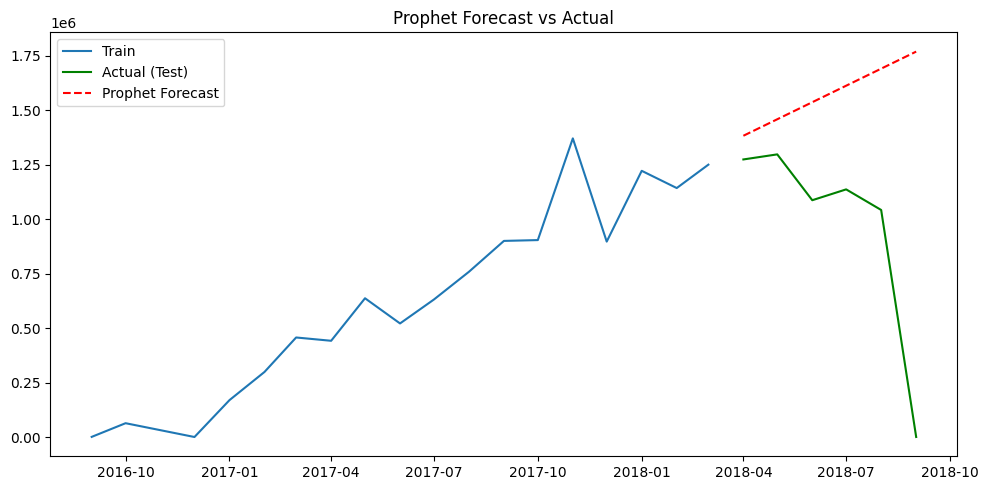


=== Model Comparison ===
  Model             MAE       RMSE     MAPE %
  ARIMA       284551.96  503665.86 139340.98%
  Prophet     602231.00  818215.97 203361.74%


In [ ]:
# Step 7 - Perform Prophet Metrics (Train/Test Split)
from prophet import Prophet

prophet_train = train_data.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_test = test_data.reset_index()
prophet_test.columns = ['ds', 'y']

m = Prophet()
m.fit(prophet_train)

future_test   = m.make_future_dataframe(periods=TEST_STEPS, freq='M')
forecast_test = m.predict(future_test)

prophet_pred = forecast_test.tail(TEST_STEPS)['yhat'].values
actual_vals  = prophet_test['y'].values

mae_p  = mean_absolute_error(actual_vals, prophet_pred)
rmse_p = np.sqrt(mean_squared_error(actual_vals, prophet_pred))
mape_p = np.mean(np.abs((actual_vals - prophet_pred) / actual_vals)) * 100

print('=== Prophet Evaluation (last 6 months as test) ===')
print(f'  MAE  : {mae_p:.2f}')
print(f'  RMSE : {rmse_p:.2f}')
print(f'  MAPE : {mape_p:.2f}%')

plt.figure(figsize=(10, 5))
plt.plot(prophet_train['ds'], prophet_train['y'], label='Train')
plt.plot(prophet_test['ds'], prophet_test['y'], label = 'Actual (Test)', color = 'green')
plt.plot(prophet_test['ds'], prophet_pred, label = 'Prophet Forecast', linestyle = '--', color = 'red')
plt.title('Prophet Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

# Side-by-side comparison
print('\n=== Model Comparison ===')
print(f"  {'Model':<10} {'MAE':>10} {'RMSE':>10} {'MAPE %':>10}")
print(f"  {'ARIMA':<10} {mae:>10.2f} {rmse:>10.2f} {mape:>9.2f}%")
print(f"  {'Prophet':<10} {mae_p:>10.2f} {rmse_p:>10.2f} {mape_p:>9.2f}%")